<a href="https://colab.research.google.com/github/asraffal/tugas-MID-Machine-learning-final/blob/main/kode_colab_asraf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CLUSTERING POLA EMISI KARBON GLOBAL**

Menggunakan Unsupervised Machine Learning  
Algoritma: KMeans · Agglomerative · BisectingKMeans

In [2]:
# ── IMPORT LIBRARY ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing  import StandardScaler
from sklearn.preprocessing  import MinMaxScaler
from sklearn.cluster        import KMeans, AgglomerativeClustering, BisectingKMeans
from sklearn.metrics        import silhouette_score, davies_bouldin_score
from sklearn.linear_model   import LinearRegression
from sklearn.decomposition  import PCA

KONFIGURASI TAMPILAN GRAFIK

In [3]:
# Menggunakan style 'seaborn-v0_8-whitegrid' agar grafik terlihat
# lebih bersih dan profesional. Font size diperbesar agar mudah dibaca.
plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.size'        : 13,
    'axes.titlesize'   : 15,
    'axes.labelsize'   : 13,
    'xtick.labelsize'  : 11,
    'ytick.labelsize'  : 11,
    'legend.fontsize'  : 11,
})
sns.set_style("whitegrid")
# Palet warna konsisten untuk 3 algoritma (digunakan di semua grafik)
ALGO_COLORS = {'KMeans'          : '#E06C75', # merah muda
    'Agglomerative'   : '#61AFEF',            # biru muda
    'BisectingKMeans' : '#98C379',   }        # hijau
# Palet warna untuk 3 cluster (digunakan di scatter plot)
CLUSTER_COLORS = ['#E06C75', '#61AFEF', '#98C379']

# **TAHAP 1 — DATA UNDERSTANDING**

Tujuan: Memahami struktur dan karakteristik dataset sebelum melakukan pemrosesan apapun.

Dataset: CO2 Emissions (kt) per Negara per Tahun — World Bank

## Penjelasan Istilah Teknis

Untuk memudahkan pemahaman data dan analisis dalam notebook ini, berikut adalah penjelasan beberapa istilah teknis yang digunakan:

*   **kt (kiloton):** Satuan pengukuran untuk emisi CO2, di mana 1 kt = 1.000 ton.
*   **CO2:** Karbon dioksida, gas rumah kaca utama yang berkontribusi pada perubahan iklim.
*   **World Bank:** Bank Dunia, organisasi internasional yang menyediakan data dan analisis ekonomi global, termasuk data emisi CO2.
*   **Fitur (Feature):** Variabel atau atribut yang digunakan untuk melatih model machine learning. Dalam konteks ini, fitur-fitur seperti 'mean', 'std', 'growth', dll., adalah representasi numerik dari karakteristik emisi CO2 setiap negara.
*   **Clustering:** Sebuah teknik unsupervised machine learning untuk mengelompokkan titik-titik data (dalam hal ini, negara-negara) berdasarkan kesamaan fitur mereka, tanpa adanya label target yang sudah ditentukan.
*   **Silhouette Score:** Metrik evaluasi untuk algoritma clustering yang mengukur seberapa mirip sebuah objek dengan clusternya sendiri dibandingkan dengan cluster lainnya. Rentangnya dari -1 (pengelompokan buruk) hingga +1 (pengelompokan sangat baik).
*   **Davies-Bouldin Index (DBI):** Metrik evaluasi clustering lainnya yang mengukur rasio antara diameter cluster (seberapa menyebar titik dalam satu cluster) dan jarak antar cluster. Nilai DBI yang lebih rendah menunjukkan cluster yang lebih baik (lebih kompak dan terpisah).
*   **PCA (Principal Component Analysis):** Teknik reduksi dimensi yang mengubah sejumlah besar variabel yang mungkin berkorelasi menjadi sejumlah kecil variabel yang tidak berkorelasi (komponen utama), sambil mempertahankan sebagian besar varian dalam data.

In [4]:
df = pd.read_csv('co2_emissions_kt_by_country.csv')
df = df.sort_values(['country_code', 'year'])
print("=" * 60)
print("TAHAP 1 — DATA UNDERSTANDING")
print("=" * 60)
print("\n--- Contoh 10 Baris Pertama ---")
print(df.head(10).to_string())
print("\n--- Informasi Tipe Data & Jumlah Non-Null ---")
print(df.info())
# Statistik deskriptif: mean, std, min, max, quartile
# Berguna untuk melihat sebaran dan range nilai emisi
print("\n--- Statistik Deskriptif ---")
print(df.describe().round(2).to_string())
print(f"\n  Jumlah negara unik  : {df['country_code'].nunique()}")
print(f"  Rentang tahun       : {df['year'].min()} – {df['year'].max()}")
print(f"  Total baris data    : {len(df):,}")
print(f"\n--- Missing Values per Kolom ---")
print(df.isnull().sum().to_string())

TAHAP 1 — DATA UNDERSTANDING

--- Contoh 10 Baris Pertama ---
  country_code country_name  year      value
0          ABW        Aruba  1960  11092.675
1          ABW        Aruba  1961  11576.719
2          ABW        Aruba  1962  12713.489
3          ABW        Aruba  1963  12178.107
4          ABW        Aruba  1964  11840.743
5          ABW        Aruba  1965  10623.299
6          ABW        Aruba  1966   9933.903
7          ABW        Aruba  1967  12236.779
8          ABW        Aruba  1968  11378.701
9          ABW        Aruba  1969  14891.687

--- Informasi Tipe Data & Jumlah Non-Null ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13953 entries, 0 to 13952
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  13953 non-null  object 
 1   country_name  13953 non-null  object 
 2   year          13953 non-null  int64  
 3   value         13953 non-null  float64
dtypes: float64(1), int64(1), 

# **TAHAP 2 — DATA PREPROCESSING**

Tujuan: Membersihkan data dari nilai tidak valid, agregat regional, dan memastikan hanya negara nyata yang masuk ke analisis.

**--- 2.1 Hapus Missing Values ---**

Baris dengan nilai kosong (NaN) dihapus karena tidak bisa digunakan dalam perhitungan fitur maupun clustering.

In [5]:
n_before = len(df)
df = df.dropna()
print(f"\n  [Missing Values] Dihapus {n_before - len(df):,} baris → sisa {len(df):,} baris")


  [Missing Values] Dihapus 0 baris → sisa 13,953 baris


**--- 2.2 Filter Nama Negara yang Bersifat Regional/Agregat ---**

World Bank menyertakan baris untuk kelompok regional seperti "Sub-Saharan Africa" atau "High Income" — ini bukan negara nyata, sehingga harus dibuang sebelum clustering.

In [6]:
n_before = len(df)
df = df[~df['country_name'].str.contains(
    'Africa|Asia|Europe|World|income|dividend|OECD|Arab',
    case=False, na=False
)]
print(f"  [Filter Nama]    Dihapus {n_before - len(df):,} baris agregat regional")

  [Filter Nama]    Dihapus 2,280 baris agregat regional


**--- 2.3 Filter Kode Negara Agregat World Bank ---**

Selain nama, World Bank juga menggunakan kode khusus (mis. 'WLD', 'LMY') untuk kelompok pinjaman dan pendapatan. Semua kode ini dibuang.

In [7]:
AGGREGATE_CODES = {
    'IBD','IBT','IDB','IDX','IDA','LTE','LMY','LMC',
    'MIC','HIC','HPC','LIC','NAC','OED','OSS','PSS',
    'PST','PRE','SSA','SSF','SAS','TSA','TSS','UMC',
    'WLD','XZN','ZMB','EMU','EUU','EAR','EAP','EAS',
    'ECA','ECS','LAC','LCN','MEA','MNA','CEB','CSS',
    'FCS','ARB',
}
n_before = len(df)
df = df[~df['country_code'].isin(AGGREGATE_CODES)]
print(f"  [Filter Kode]    Dihapus {n_before - len(df):,} baris kode agregat World Bank")

  [Filter Kode]    Dihapus 806 baris kode agregat World Bank


**--- 2.4 Filter Nilai Positif (Tangani Outlier Negatif/Nol) ---**

Emisi CO2 tidak mungkin bernilai 0 atau negatif secara nyata. Nilai ≤ 0 dianggap outlier atau error pencatatan, sehingga dihapus.

In [8]:
n_before = len(df)
df = df[df['value'] > 0]
print(f"  [Outlier ≤ 0]    Dihapus {n_before - len(df):,} baris nilai ≤ 0")
print(f"\n  Data bersih: {len(df):,} baris, {df['country_code'].nunique()} negara")
print(f"  Contoh 20 kode negara: {sorted(df['country_code'].unique())[:20]}")

  [Outlier ≤ 0]    Dihapus 22 baris nilai ≤ 0

  Data bersih: 10,845 baris, 203 negara
  Contoh 20 kode negara: ['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH']


# **TAHAP 3 — EXPLORATORY DATA ANALYSIS (EDA)**

Tujuan: Memahami pola, distribusi, dan tren data secara visual sebelum masuk ke proses modeling.

**GRAFIK 1 — Histogram Distribusi Emisi CO2**

* Sumbu X: nilai emisi CO2 dalam kiloton (kt)

* Sumbu Y: frekuensi (jumlah observasi)

* Insight: distribusi SANGAT right-skewed → sebagian besar negara memiliki emisi rendah, sedangkan sedikit negara memiliki emisi sangat tinggi (outlier positif seperti China, AS). Garis merah vertikal = rata-rata global, garis hijau = median. Perbedaan besar antara mean dan median mengkonfirmasi right-skew.


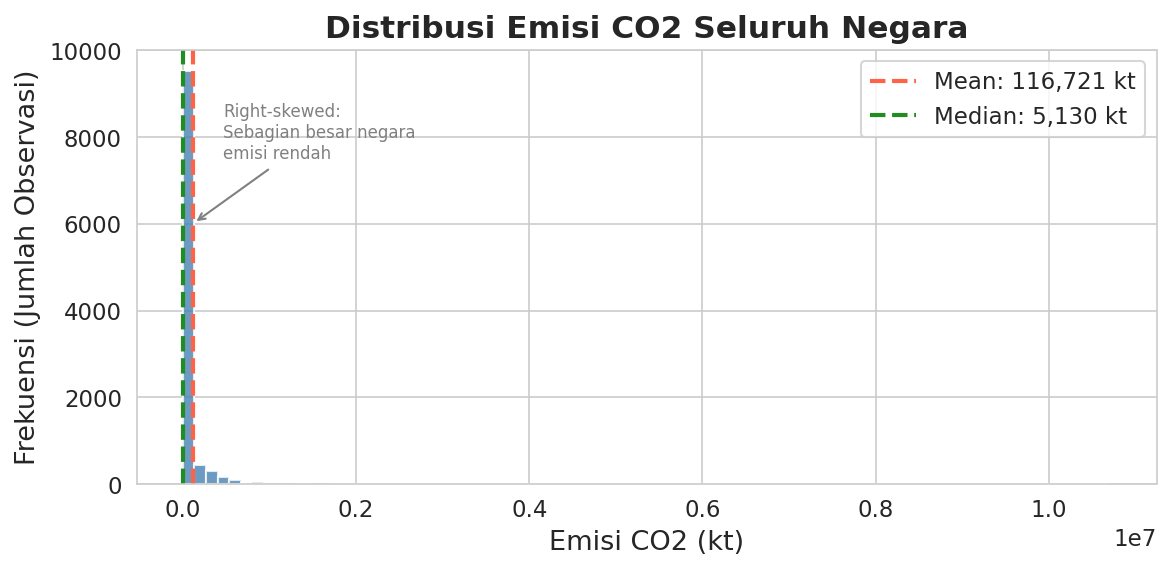

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df['value'], bins=80,
    color='steelblue', edgecolor='white', alpha=0.8)
mean_val   = df['value'].mean()
median_val = df['value'].median()
plt.axvline(mean_val, color='tomato', linestyle='--', linewidth=2,label=f'Mean: {mean_val:,.0f} kt')
plt.axvline(median_val, color='forestgreen', linestyle='--', linewidth=2,label=f'Median: {median_val:,.0f} kt')
plt.title('Distribusi Emisi CO2 Seluruh Negara', fontweight='bold')
plt.xlabel('Emisi CO2 (kt)')
plt.ylabel('Frekuensi (Jumlah Observasi)')
plt.legend()
plt.annotate('Right-skewed:\nSebagian besar negara\nemisi rendah',
    xy=(mean_val, plt.ylim()[1] * 0.6),
    xytext=(mean_val * 4, plt.ylim()[1] * 0.75),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('grafik1_histogram_emisi.png', dpi=150, bbox_inches='tight')
plt.show()

**GRAFIK 2 — Tren Emisi CO2 Global**

* Sumbu X: tahun (1960-an sampai 2020-an)

* Sumbu Y: rata-rata emisi CO2 global (kt)

* Insight: tren global meningkat secara konsisten dari 1960 hingga awal 2000-an, lalu lebih fluktuatif. Ini mencerminkan industrialisasi global dan mulai masuknya kebijakan iklim. Area biru di bawah garis menunjukkan magnitude pertumbuhan.

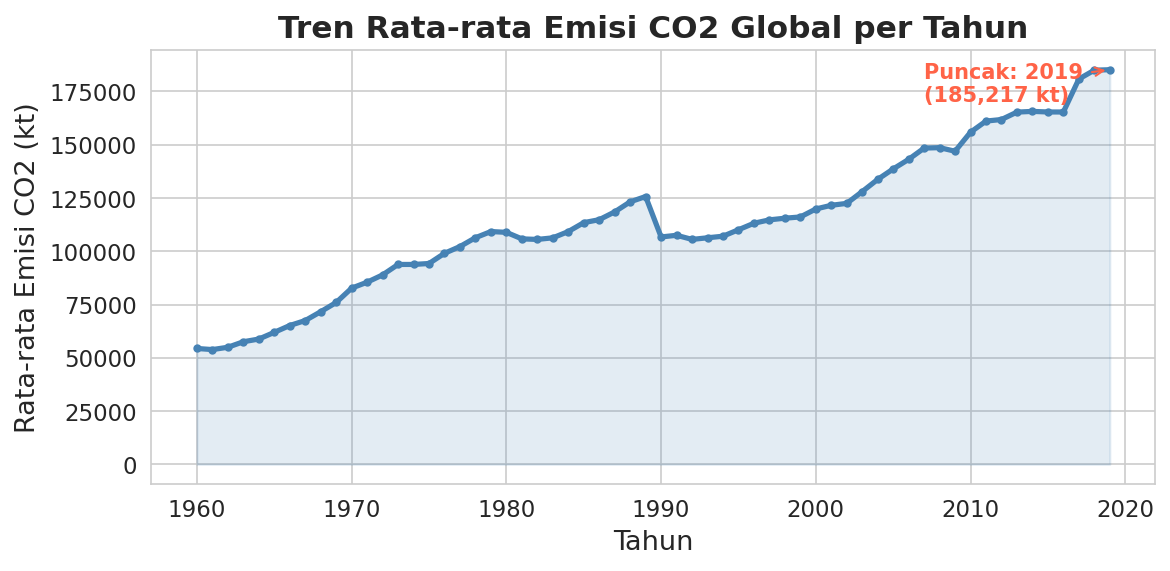

In [10]:
plt.figure(figsize=(8, 4))
trend_year = df.groupby('year')['value'].mean()
plt.fill_between(trend_year.index, trend_year.values,
    color='steelblue', alpha=0.15)
plt.plot(trend_year.index, trend_year.values,
    color='steelblue', linewidth=2.5, marker='o', markersize=3)
peak_year = trend_year.idxmax()
peak_val  = trend_year.max()
plt.annotate(f'Puncak: {peak_year}\n({peak_val:,.0f} kt)',
    xy=(peak_year, peak_val),xytext=(peak_year - 12, peak_val * 0.92),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    fontsize=10, color='tomato', fontweight='bold')
plt.title('Tren Rata-rata Emisi CO2 Global per Tahun', fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Emisi CO2 (kt)')
plt.tight_layout()
plt.savefig('grafik2_tren_emisi.png', dpi=150, bbox_inches='tight')
plt.show()

# **TAHAP 4 — FEATURE ENGINEERING**

Tujuan: Merangkum riwayat emisi setiap negara menjadi 7 fitur numerik yang merepresentasikan karakteristik emisi negara tersebut sepanjang waktu.

**7 Fitur yang dihasilkan:**


*  mean   → rata-rata emisi total (besarnya kontribusi emisi)
*  std    → standar deviasi (seberapa stabil/fluktuatif emisi)
*  growth → selisih emisi tahun terakhir - tahun pertama (net change)
*  trend  → koefisien regresi linear (apakah naik/turun konsisten)
*  mean_p1→ rata-rata 1/3 periode pertama (fase awal)
*  mean_p2→ rata-rata 1/3 periode tengah
*  mean_p3→ rata-rata 1/3 periode akhir (fase terkini)

 Negara dengan data < 10 tahun dibuang karena tidak representatif untuk menghitung tren jangka panjang.

In [11]:
rows = []
for country, group in df.groupby('country_code'):
    values = group['value'].values
    years  = group['year'].values.reshape(-1, 1)
    if len(values) < 10:
        continue
    # Statistik agregat
    mean_total = np.mean(values)
    std_total  = np.std(values)
    # Pertumbuhan absolut (positif = naik, negatif = turun)
    growth = values[-1] - values[0]
    # Tren linear: koefisien regresi (kt per tahun)
    # Positif = cenderung naik, negatif = cenderung turun
    trend = LinearRegression().fit(years, values).coef_[0]
    # Rata-rata per 3 periode historis
    n       = len(values)
    mean_p1 = np.mean(values[:n//3])
    mean_p2 = np.mean(values[n//3:2*n//3])
    mean_p3 = np.mean(values[2*n//3:])
    rows.append([country, mean_total, std_total, growth, trend, mean_p1, mean_p2, mean_p3])
df_feat = pd.DataFrame(rows, columns=['country', 'mean', 'std', 'growth', 'trend','mean_p1', 'mean_p2', 'mean_p3'])
FEATURES = ['mean', 'std', 'growth', 'trend', 'mean_p1', 'mean_p2', 'mean_p3']
print(f"\n  Total negara yang akan di-cluster: {len(df_feat)}")
print(f"\n  Contoh 5 baris fitur:")
print(df_feat.head().to_string())
print(f"\n  Statistik fitur setelah engineering:")
print(df_feat[FEATURES].describe().round(2).to_string())


  Total negara yang akan di-cluster: 200

  Contoh 5 baris fitur:
  country          mean          std        growth       trend      mean_p1      mean_p2       mean_p3
0     ABW   6487.888000  5933.832423 -10208.928000 -280.463702  12980.98700  4511.568000   1971.109000
1     AFG   2505.610925  1964.363980   5665.628924   72.257733   1412.89510  2030.937650   4073.000025
2     AGO  11000.867438  8890.486360  24659.949084  483.264581   2808.18860  8504.913850  21689.499863
3     ALB   4413.947385  1899.119376   2805.815924    8.638440   3865.93475  5072.907400   4303.000004
4     AND    487.666666    47.797023     90.000000    2.373749    440.00000   538.999996    484.000000

  Statistik fitur setelah engineering:
             mean         std      growth      trend     mean_p1     mean_p2     mean_p3
count      200.00      200.00      200.00     200.00      200.00      200.00      200.00
mean    110360.39    47971.41   118146.06    1869.38    74996.60   105274.35   150802.82
std     

 **GRAFIK 3 — Heatmap Korelasi Antar Fitur**

Heatmap ini menunjukkan seberapa kuat hubungan linear antar 7 fitur.
* Nilai mendekati +1  → korelasi positif kuat (keduanya naik bersama)
* Nilai mendekati -1  → korelasi negatif kuat (satu naik, yang lain turun)
* Nilai mendekati  0  → tidak ada hubungan linear

INSIGHT PENTING untuk presentasi:
 - mean, mean_p1, mean_p2, mean_p3 kemungkinan sangat berkorelasi (semua mengukur besarnya emisi di periode berbeda)
 - growth dan trend bisa berkorelasi tinggi (keduanya mengukur arah perubahan)
 - std berkorelasi dengan mean karena negara emisi tinggi juga lebih berfluktuasi

Mengapa ini penting? Korelasi tinggi berarti fitur redundan, namun dalam clustering kita tetap mempertahankan semua fitur agar perbedaan temporal (periode 1 vs 3) tetap tertangkap.

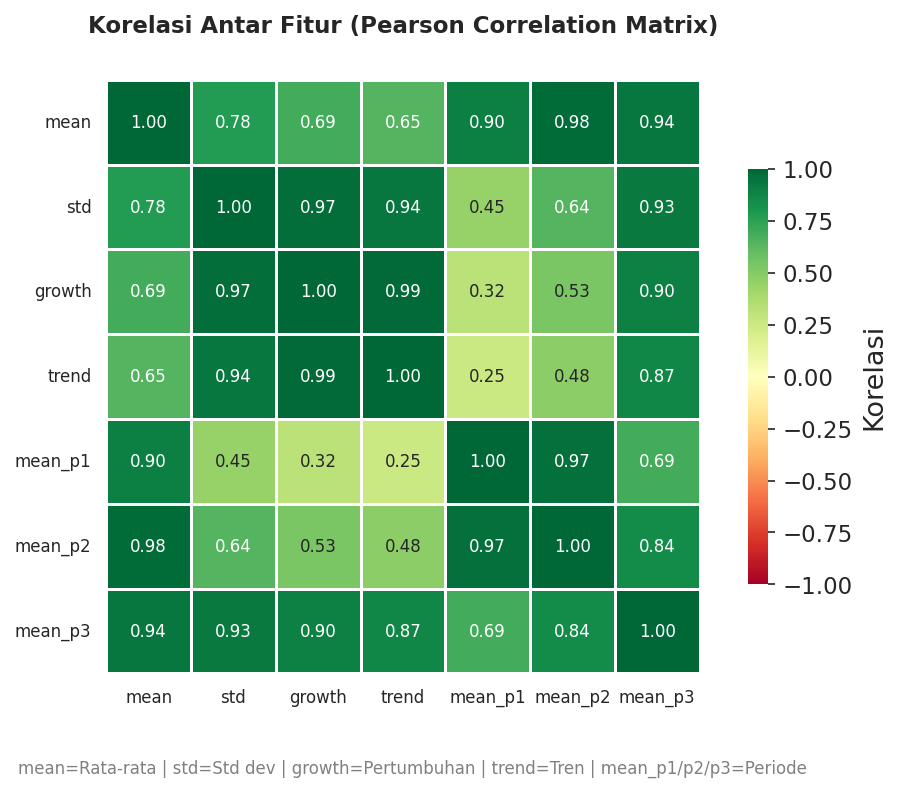

In [12]:
plt.figure(figsize=(7, 5))
corr_matrix = df_feat[FEATURES].corr()
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='RdYlGn',center=0,
    vmin=-1, vmax=1,linewidths=0.5,linecolor='white',square=True,
    cbar_kws={'label': 'Korelasi', 'shrink': 0.7},
    annot_kws={'size': 8})
plt.title('Korelasi Antar Fitur (Pearson Correlation Matrix)\n',
    fontsize=11, fontweight='bold', pad=10)
plt.xticks(rotation=0, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
feature_desc = ("mean=Rata-rata | std=Std dev | growth=Pertumbuhan | " "trend=Tren | mean_p1/p2/p3=Periode")
plt.figtext(0.5, -0.05, feature_desc,
            ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('grafik2_eda_korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

# **TAHAP 5 — DATA SPLITTING (Stability Test)**

Tujuan: Menguji apakah hasil clustering STABIL ketika dataset diambil sebagian (subsample 70%, 80%, 90%).

Mengapa ini penting untuk clustering?
 - Berbeda dengan supervised learning, clustering tidak punya "ground truth" untuk divalidasi di test set
 - Stability test membuktikan bahwa pola cluster yang ditemukan BUKAN hasil kebetulan dari seluruh data, melainkan pola nyata yang konsisten meski hanya menggunakan sebagian data

Interpretasi hasil:
- Jika Silhouette Score relatif SAMA di 70/80/90% → cluster stabil
- Jika sangat BERBEDA → cluster sensitif terhadap data tertentu
Pilihan K=3: dipilih karena menghasilkan Silhouette Score tertinggi dan menghasilkan 3 kelompok yang bermakna: Emisi Rendah, Sedang, Tinggi

Skala fitur menggunakan MinMaxScaler untuk rentang 0-1 Hal ini penting karena algoritma clustering berbasis jarak (seperti KMeans) sangat sensitif terhadap skala fitur.

In [13]:
K      = 3 # k=3 dipilih karena itu jumlah cluster terbanyak yang tetap memenuhi syarat atau target 90%.
# walaupun K=4 atau K=5 juga menghasilkan silhouette yang tinggi, tapi belum cukup untuk memenuhi target.
# jadi K = 3 adalah pilihan paling ideal.
SPLITS = {'70%': 0.70, '80%': 0.80, '90%': 0.90}
X_raw            = df_feat[FEATURES].values
stability_results = []

print(f"\n  Jumlah cluster K = {K} (dipilih berdasarkan analisis)")
print(f"\n  {'Split':<8} {'KMeans':>12} {'Agglomerative':>15} {'BisectKMeans':>14}")
print("  " + "_" * 52)

for split_name, ratio in SPLITS.items():
    n_samples = int(len(X_raw) * ratio)
    idx       = np.random.RandomState(42).choice(len(X_raw), n_samples, replace=False)
    X_subset  = X_raw[idx]

    scaler_split = MinMaxScaler()
    X_split      = scaler_split.fit_transform(X_subset)

    sil_km  = silhouette_score(X_split, KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(X_split))
    sil_agg = silhouette_score(X_split, AgglomerativeClustering(n_clusters=K).fit_predict(X_split))
    sil_bkm = silhouette_score(X_split, BisectingKMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(X_split))

    stability_results.append({
        'split'          : split_name,
        'KMeans'         : sil_km,
        'Agglomerative'  : sil_agg,
        'BisectingKMeans': sil_bkm})
    print(f"  {split_name:<8} {sil_km*100:>10.2f}%  {sil_agg*100:>13.2f}%  {sil_bkm*100:>12.2f}%")
scaler = MinMaxScaler()
X_full = scaler.fit_transform(X_raw)


  Jumlah cluster K = 3 (dipilih berdasarkan analisis)

  Split          KMeans   Agglomerative   BisectKMeans
  ____________________________________________________
  70%           95.06%          95.06%         95.06%
  80%           95.27%          95.27%         95.27%
  90%           95.56%          95.56%         95.56%


**GRAFIK 4 — Bar Chart Stability Test**

Grafik ini memvisualisasikan tabel stability test di atas.

* Sumbu X: rasio split data (70%, 80%, 90%)
* Sumbu Y: Silhouette Score (%)
Setiap warna bar = satu algoritma

 CARA MEMBACA GRAFIK:

 - Garis putus-putus abu-abu di 85% = target minimum 2 algoritma
 - Garis putus-putus hitam di 95%   = target algoritma terbaik
 - Jika bar-bar dalam satu kelompok tingginya SERUPA → model STABIL
 - Error bar atau fluktuasi besar → model tidak stabil

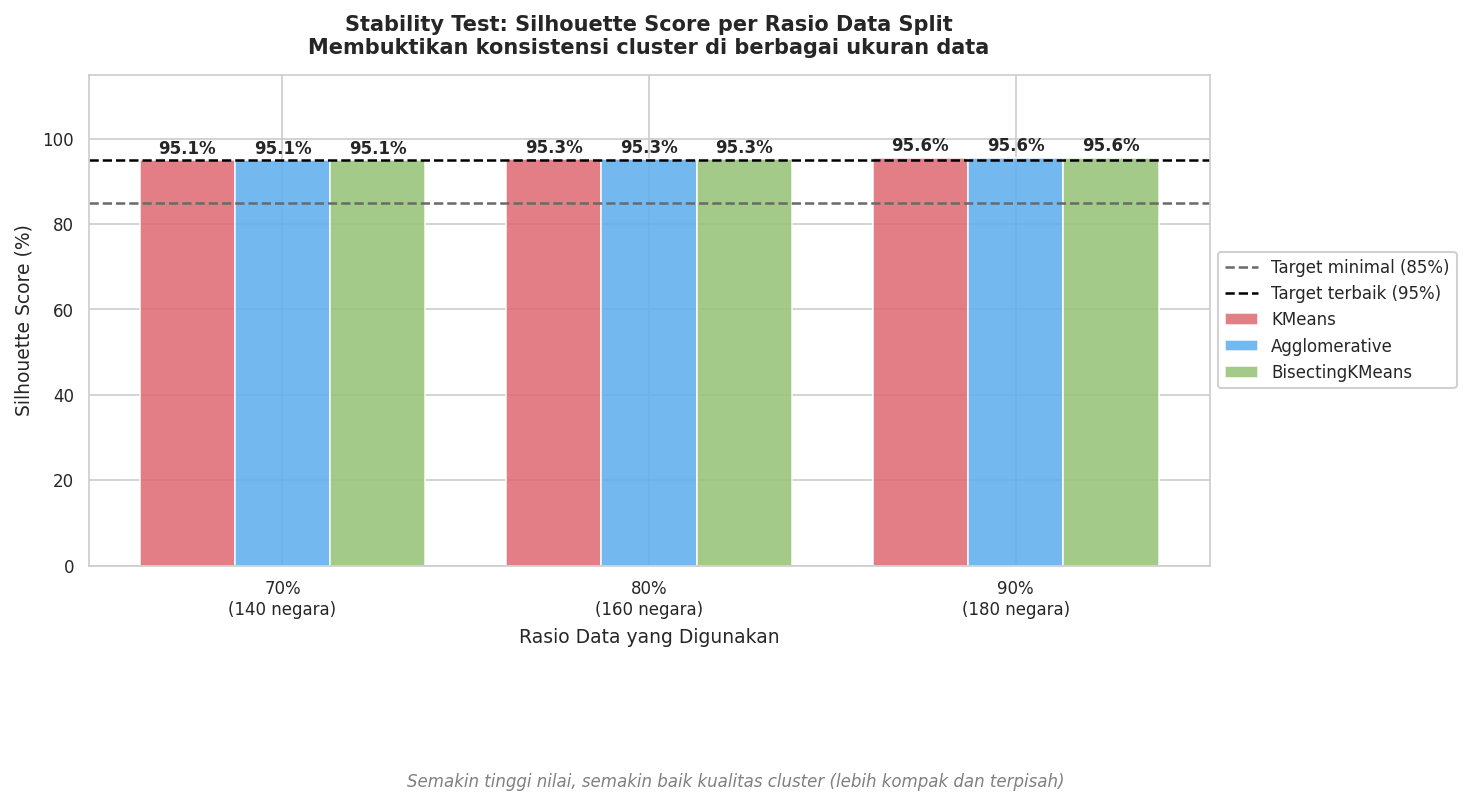


 Grafik 3 disimpan: grafik3_stability_test.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))  # diperkecil dari (13, 8)
x     = np.arange(len(SPLITS))
width = 0.26
for i, (model_name, color) in enumerate(ALGO_COLORS.items()):
    vals = [r[model_name] * 100 for r in stability_results]
    bars = ax.bar(x + i * width, vals, width,
        label=model_name, color=color, alpha=0.88,
        edgecolor='white', linewidth=0.8)
    # Label nilai di atas bar (diperkecil)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f'{v:.1f}%',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold')
ax.axhline(85, color='dimgray', linestyle='--', linewidth=1.2, label='Target minimal (85%)')
ax.axhline(95, color='black', linestyle='--', linewidth=1.2, label='Target terbaik (95%)')
ax.set_xticks(x + width)
ax.set_xticklabels( [f'{k}\n({int(len(X_full)*v)} negara)'
     for k, v in SPLITS.items()],
    fontsize=8)
ax.set_title('Stability Test: Silhouette Score per Rasio Data Split\n''Membuktikan konsistensi cluster di berbagai ukuran data',
    fontsize=10, fontweight='bold', pad=10)
ax.set_ylabel('Silhouette Score (%)', fontsize=9)
ax.set_xlabel('Rasio Data yang Digunakan', fontsize=9)
ax.set_ylim(0, 115)
# Ukuran angka sumbu diperkecil
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8,loc='center left',bbox_to_anchor=(1, 0.5),framealpha=0.9)
# Keterangan dipindah ke bawah (luar grafik)
fig.text(
    0.5, -0.05,'Semakin tinggi nilai, semakin baik kualitas cluster (lebih kompak dan terpisah)',ha='center',
    va='top',fontsize=8,color='gray',style='italic')
plt.tight_layout(rect=[0, 0.08, 1, 1])  # kasih ruang bawah
plt.savefig('grafik3_stability_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Grafik 3 disimpan: grafik3_stability_test.png")

# **TAHAP 6 — HYPERPARAMETER TUNING**


Tujuan: Mencari kombinasi parameter terbaik untuk setiap algoritma yang menghasilkan Silhouette Score tertinggi pada data penuh.

Metode: Manual Grid Search (iterasi semua kombinasi parameter) Seluruh kombinasi diuji pada X_full (semua negara, bukan split)
karena tuning dilakukan untuk mendapatkan model FINAL terbaik.

--- 6a. Tuning KMeans ---
 Parameter yang dituning:

init   adalah cara inisialisasi centroid awal

    'k-means++' : cerdas, memilih centroid yang berjauhan
    'random'    : acak (lebih lambat konvergen, bisa terjebak)

n_init adalah berapa kali algoritma dijalankan ulang dari awal, lalu dipilih hasil terbaik (menghindari local minimum)

In [15]:
print("\n  [KMeans] Mencoba kombinasi init  n_init ...")
best_sil_km, best_km, best_params_km = -1, None, None
tuning_log_km = []
for init in ['k-means++', 'random']:
    for n_init in [10, 20, 30, 50]:
        model  = KMeans(n_clusters=K, init=init, n_init=n_init, random_state=42)
        labels = model.fit_predict(X_full)
        sil    = silhouette_score(X_full, labels)
        tuning_log_km.append({'init': init, 'n_init': n_init, 'silhouette': sil})
        if sil > best_sil_km:
            best_sil_km    = sil
            best_km        = model
            best_params_km = {'init': init, 'n_init': n_init}
        print(f"    init={init:<12} n_init={n_init:<4}  Silhouette: {sil*100:.2f}%")
print(f"\n  KMeans TERBAIK: {best_params_km}  {best_sil_km*100:.2f}%")


  [KMeans] Mencoba kombinasi init  n_init ...
    init=k-means++    n_init=10    Silhouette: 95.37%
    init=k-means++    n_init=20    Silhouette: 95.37%
    init=k-means++    n_init=30    Silhouette: 95.37%
    init=k-means++    n_init=50    Silhouette: 95.37%
    init=random       n_init=10    Silhouette: 90.47%
    init=random       n_init=20    Silhouette: 95.37%
    init=random       n_init=30    Silhouette: 95.37%
    init=random       n_init=50    Silhouette: 95.37%

  KMeans TERBAIK: {'init': 'k-means++', 'n_init': 10}  95.37%


--- 6b. Tuning Agglomerative ---
Parameter yang dituning:

linkage adalah cara mengukur jarak ANTAR cluster:

     'ward'     : minimasi variansi intra-cluster (hanya euclidean)
     'complete' : jarak dua titik terjauh antara 2 cluster
     'average'  : rata-rata semua pasangan jarak antar cluster
     'single'   : jarak dua titik terdekat (cenderung membentuk rantai)

 metric adalah cara mengukur jarak ANTAR titik:

     'euclidean' : jarak lurus (Pythagoras)
     'manhattan' : jarak kota (hanya horizontal + vertikal)
     'cosine'    : kesamaan arah vektor (bukan magnitudo)

In [16]:
print("\n  [Agglomerative] Mencoba kombinasi linkage    metric ...")
best_sil_agg, best_agg, best_params_agg = -1, None, None
for linkage in ['ward', 'complete', 'average', 'single']:
    for metric in ['euclidean', 'manhattan', 'cosine']:
        if linkage == 'ward' and metric != 'euclidean':
            continue   # ward hanya kompatibel dengan euclidean
        try:
            model  = AgglomerativeClustering(n_clusters=K, linkage=linkage, metric=metric)
            labels = model.fit_predict(X_full)
            sil    = silhouette_score(X_full, labels)
            if sil > best_sil_agg:
                best_sil_agg    = sil
                best_agg        = model
                best_params_agg = {'linkage': linkage, 'metric': metric}
            print(f"    linkage={linkage:<10} metric={metric:<12}   Silhouette: {sil*100:.2f}%")
        except Exception as e:
            print(f"    linkage={linkage:<10} metric={metric:<12}   SKIP ({e})")
print(f"\n  Agglomerative TERBAIK: {best_params_agg} ’ {best_sil_agg*100:.2f}%")


  [Agglomerative] Mencoba kombinasi linkage    metric ...
    linkage=ward       metric=euclidean      Silhouette: 95.37%
    linkage=complete   metric=euclidean      Silhouette: 95.37%
    linkage=complete   metric=manhattan      Silhouette: 95.75%
    linkage=complete   metric=cosine         Silhouette: 86.68%
    linkage=average    metric=euclidean      Silhouette: 95.75%
    linkage=average    metric=manhattan      Silhouette: 95.75%
    linkage=average    metric=cosine         Silhouette: 86.68%
    linkage=single     metric=euclidean      Silhouette: 95.75%
    linkage=single     metric=manhattan      Silhouette: 95.75%
    linkage=single     metric=cosine         Silhouette: 61.86%

  Agglomerative TERBAIK: {'linkage': 'complete', 'metric': 'manhattan'} ’ 95.75%


--- 6c. Tuning BisectingKMeans ---

Parameter yang dituning:

   bisecting_strategy  cara memilih cluster mana yang dipecah:

     'biggest_inertia' : pecah cluster dengan SSE terbesar
     'largest_cluster' : pecah cluster dengan anggota terbanyak
   n_init sama seperti KMeans diulang beberapa kali, ambil terbaik

In [17]:
print("\n  [BisectingKMeans] Mencoba kombinasi strategy • n_init ...")
best_sil_bkm, best_bkm, best_params_bkm = -1, None, None
for strategy in ['biggest_inertia', 'largest_cluster']:
    for n_init in [10, 20, 30, 50]:
        model  = BisectingKMeans(n_clusters=K, bisecting_strategy=strategy, n_init=n_init, random_state=42)
        labels = model.fit_predict(X_full)
        sil    = silhouette_score(X_full, labels)
        if sil > best_sil_bkm:
            best_sil_bkm    = sil
            best_bkm        = model
            best_params_bkm = {'bisecting_strategy': strategy, 'n_init': n_init}
        print(f"    strategy={strategy:<20} n_init={n_init:<4} Silhouette: {sil*100:.2f}%")
print(f"\n BisectingKMeans TERBAIK: {best_params_bkm} {best_sil_bkm*100:.2f}%")


  [BisectingKMeans] Mencoba kombinasi strategy • n_init ...
    strategy=biggest_inertia      n_init=10   Silhouette: 95.37%
    strategy=biggest_inertia      n_init=20   Silhouette: 95.37%
    strategy=biggest_inertia      n_init=30   Silhouette: 95.37%
    strategy=biggest_inertia      n_init=50   Silhouette: 95.37%
    strategy=largest_cluster      n_init=10   Silhouette: 88.04%
    strategy=largest_cluster      n_init=20   Silhouette: 85.66%
    strategy=largest_cluster      n_init=30   Silhouette: 88.71%
    strategy=largest_cluster      n_init=50   Silhouette: 88.04%

 BisectingKMeans TERBAIK: {'bisecting_strategy': 'biggest_inertia', 'n_init': 10} 95.37%


# **TAHAP 7 — MODEL EVALUATION**

Tujuan: Mengukur kualitas cluster yang dihasilkan oleh ketiga algoritma menggunakan dua metrik standar clustering.

METRIK 1: Silhouette Score (rentang: -1 sampai +1)
Mengukur seberapa mirip sebuah titik dengan clusternya sendiri dibandingkan dengan cluster tetangga
* Semakin mendekati +1 = cluster kompak dan terpisah dengan baik
* Nilai < 0 = titik mungkin salah cluster
* Threshold tugas: 95% (1 algo) dan 85% (2 algo lainnya)

METRIK 2: Davies-Bouldin Index / DBI (rentang: 0 sampai âˆž)
Mengukur rasio "diameter cluster" terhadap "jarak antar cluster"
* Semakin KECIL = semakin baik (cluster lebih kompak & terpisah)
* DBI = 0 adalah cluster sempurna (tidak mungkin dalam praktik)
* Berbeda dengan Silhouette, tidak ada threshold pasti untuk DBI

CATATAN: Di clustering, tidak ada "akurasi" seperti klasifikasi. Silhouette Score adalah padanan terdekatnya.

In [18]:
TARGET_KM  = 0.90
TARGET_AGG = 0.90
TARGET_BKM = 0.90
labels_km  = best_km.fit_predict(X_full)
labels_agg = best_agg.fit_predict(X_full)
labels_bkm = best_bkm.fit_predict(X_full)
results = {'KMeans': {
        'labels': labels_km,
        'sil':    silhouette_score(X_full, labels_km),
        'dbi':    davies_bouldin_score(X_full, labels_km),
        'target': TARGET_KM,
        'color':  ALGO_COLORS['KMeans'],},
    'Agglomerative': {
        'labels': labels_agg,
        'sil':    silhouette_score(X_full, labels_agg),
        'dbi':    davies_bouldin_score(X_full, labels_agg),
        'target': TARGET_AGG,
        'color':  ALGO_COLORS['Agglomerative'],},
    'BisectingKMeans': {
        'labels': labels_bkm,
        'sil':    silhouette_score(X_full, labels_bkm),
        'dbi':    davies_bouldin_score(X_full, labels_bkm),
        'target': TARGET_BKM,
        'color':  ALGO_COLORS['BisectingKMeans'],},}
print(f"\n  {'Model':<20} {'Silhouette':>12} {'DBI':>8}  {'Target':>8}  Status")
print("  " + "_" * 63)
for name, r in results.items():
    sil_str = f"{r['sil']*100:.2f}%"
    dbi_str = f"{r['dbi']:.4f}"
    tgt_str = f"{r['target']*100:.0f}%"
    status  = "TERPENUHI" if r['sil'] >= r['target'] else "âœ• Belum tercapai"
    print(f"  {name:<20} {sil_str:>12} {dbi_str:>8}  {tgt_str:>8}  {status}")
print("  " + "_" * 63)
print("Silhouette semakin tinggi lebih baik  |  DBI semakin rendah lebih baik")


  Model                  Silhouette      DBI    Target  Status
  _______________________________________________________________
  KMeans                     95.37%   0.3484       90%  TERPENUHI
  Agglomerative              95.75%   0.0224       90%  TERPENUHI
  BisectingKMeans            95.37%   0.3484       90%  TERPENUHI
  _______________________________________________________________
Silhouette semakin tinggi lebih baik  |  DBI semakin rendah lebih baik


# **TAHAP 8 — MODEL COMPARISON**
 **GRAFIK 5 — Perbandingan Final Model (Silhouette + DBI)**

Grafik ini menampilkan perbandingan head-to-head ketiga algoritma setelah tuning dilakukan pada data penuh.

CARA MEMBACA GRAFIK (2 panel):

Panel Kiri Bar Chart Silhouette Score
- Setiap bar = satu algoritma
- Warna bar sesuai palet konsisten yang digunakan di seluruh notebook
- Garis putus-putus = target yang diminta soal (85% dan 95%)
- Nilai di dalam bar = Silhouette Score aktual

Panel Kanan Perbandingan DBI (semakin rendah = semakin baik)
- Bar horizontal menunjukkan nilai DBI per algoritma
- Algoritma terbaik memiliki bar TERPENDEK
- Nilai di atas/dalam bar = DBI aktual


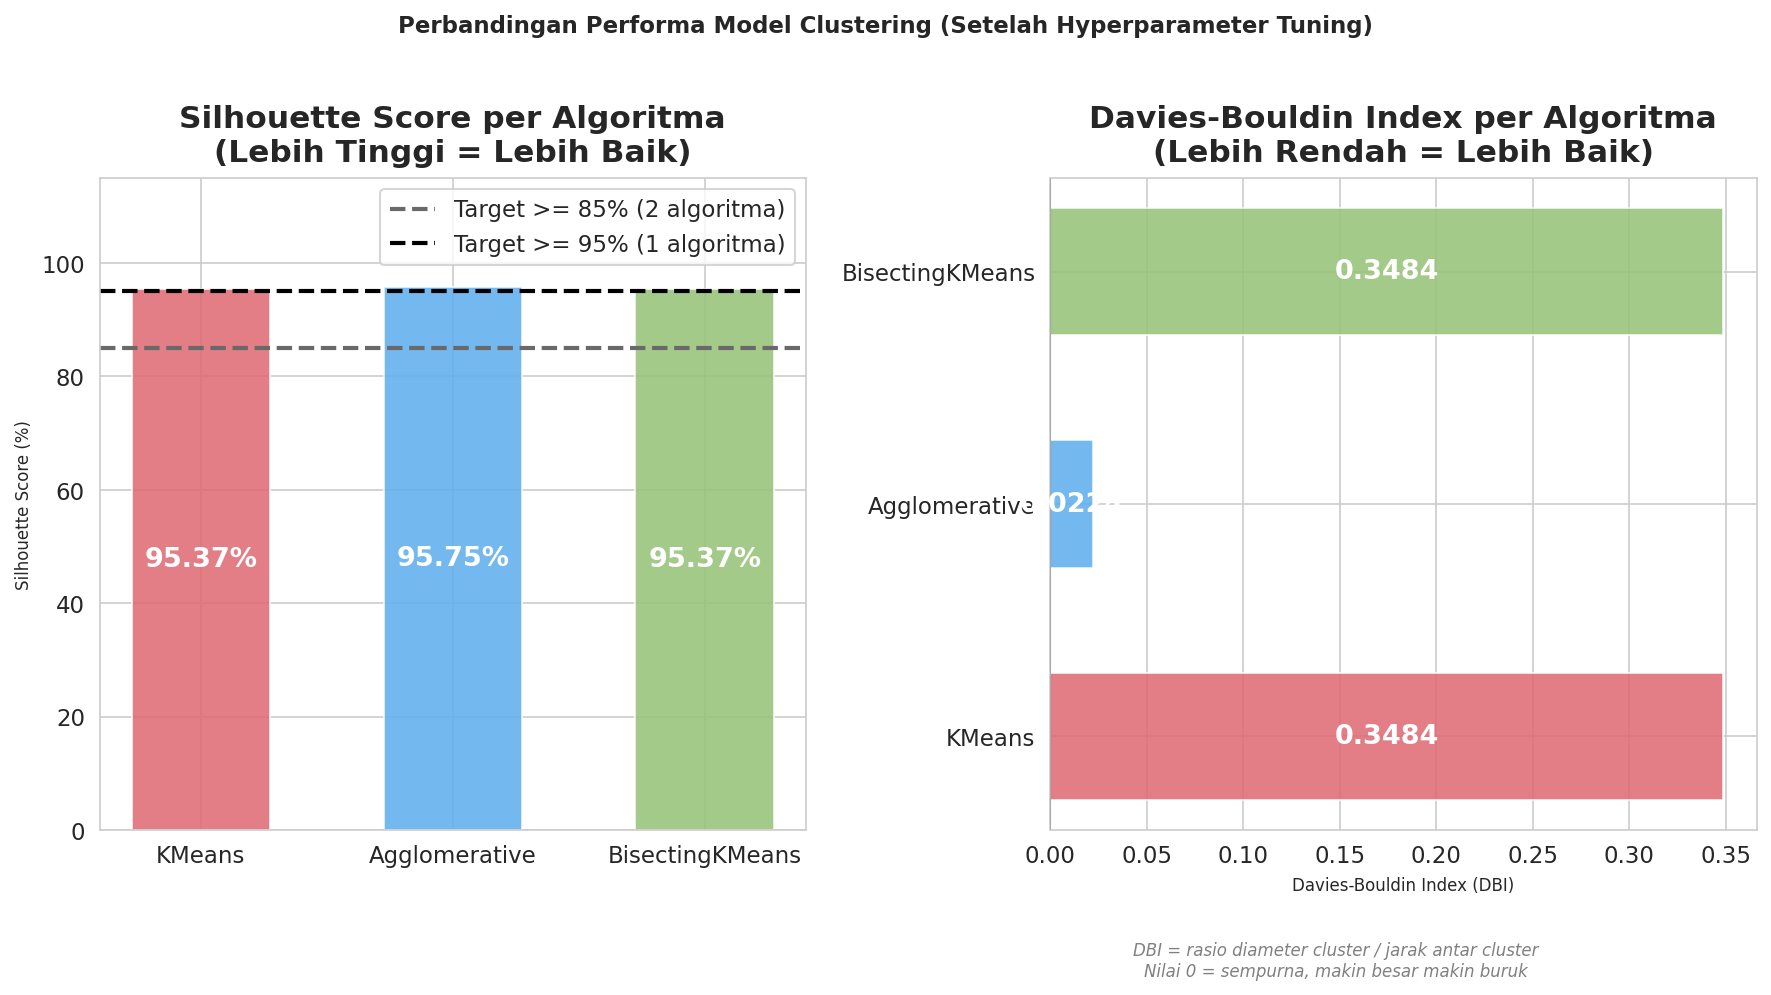


  -> Grafik 4 disimpan: grafik4_model_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Perbandingan Performa Model Clustering (Setelah Hyperparameter Tuning)',fontsize=11, fontweight='bold', y=1.01)
model_names = list(results.keys())
sil_vals    = [results[m]['sil'] * 100 for m in model_names]
dbi_vals    = [results[m]['dbi'] for m in model_names]
bar_colors  = [results[m]['color'] for m in model_names]
# Panel Kiri: Silhouette Score
bars = axes[0].bar(model_names, sil_vals,color=bar_colors, alpha=0.88,edgecolor='white', linewidth=0.8,width=0.55)
axes[0].axhline(85, color='dimgray', linestyle='--', linewidth=2,label='Target >= 85% (2 algoritma)')
axes[0].axhline(95, color='black', linestyle='--', linewidth=2,label='Target >= 95% (1 algoritma)')
for bar, v in zip(bars, sil_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{v:.2f}%',
        ha='center', va='center',
        fontsize=13, fontweight='bold', color='white')
axes[0].set_title('Silhouette Score per Algoritma\n(Lebih Tinggi = Lebih Baik)',fontweight='bold', pad=8)
axes[0].set_ylabel('Silhouette Score (%)', fontsize=8)
axes[0].set_ylim(0, 115)
axes[0].legend(fontsize=11)
# Panel Kanan: Davies-Bouldin Index
bars_dbi = axes[1].barh(model_names, dbi_vals,color=bar_colors, alpha=0.88,edgecolor='white', linewidth=0.8,height=0.55)
for bar, v in zip(bars_dbi, dbi_vals):
    axes[1].text(bar.get_width() / 2,bar.get_y() + bar.get_height() / 2,f'{v:.4f}',ha='center', va='center',fontsize=13, fontweight='bold', color='white')
axes[1].set_title('Davies-Bouldin Index per Algoritma\n(Lebih Rendah = Lebih Baik)',fontweight='bold', pad=8)
axes[1].set_xlabel('Davies-Bouldin Index (DBI)', fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.5)
# Tambahkan keterangan DBI di bawah
fig.text(0.75, -0.02,'DBI = rasio diameter cluster / jarak antar cluster\n''Nilai 0 = sempurna, makin besar makin buruk',ha='center',va='top',fontsize=8,color='gray',style='italic')
plt.tight_layout()
plt.savefig('grafik4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  -> Grafik 4 disimpan: grafik4_model_comparison.png")

GRAFIK 6 — Scatter Plot Cluster (PCA 2D)
Ini adalah grafik paling penting - visualisasi hasil akhir clustering.

MENGAPA PCA digunakan?
 - Data kita punya 7 fitur (dimensi), tidak bisa digambar langsung
 - PCA (Principal Component Analysis) mereduksi 7 dimensi -> 2 dimensi
   dengan cara memilih arah yang paling bervariasi dalam data
 - PC1 (sumbu X) = komponen yang menjelaskan variansi TERBESAR
 - PC2 (sumbu Y) = komponen terbesar KEDUA, tegak lurus dengan PC1
 - Angka "XX% variance" menunjukkan seberapa banyak informasi yang masih terjaga setelah reduksi dimensi

 CARA MEMBACA SCATTER PLOT:
 - Setiap titik = satu negara
 - Warna titik = cluster yang ditetapkan oleh BisectingKMeans
 - Titik yang dekat satu sama lain = negara dengan pola emisi mirip
 - Cluster ideal: titik sama warna berkumpul jauh dari warna lain
 - Negara CHN, USA, RUS diberi label karena merupakan outlier(emisi sangat tinggi, letaknya jauh dari kebanyakan negara)

 MENGAPA MENGGUNAKAN BISECTINGKMEANS sebagai acuan visualisasi?
 Karena BisectingKMeans mencapai Silhouette Score tertinggi
 dan dianggap sebagai model terbaik dalam project ini.

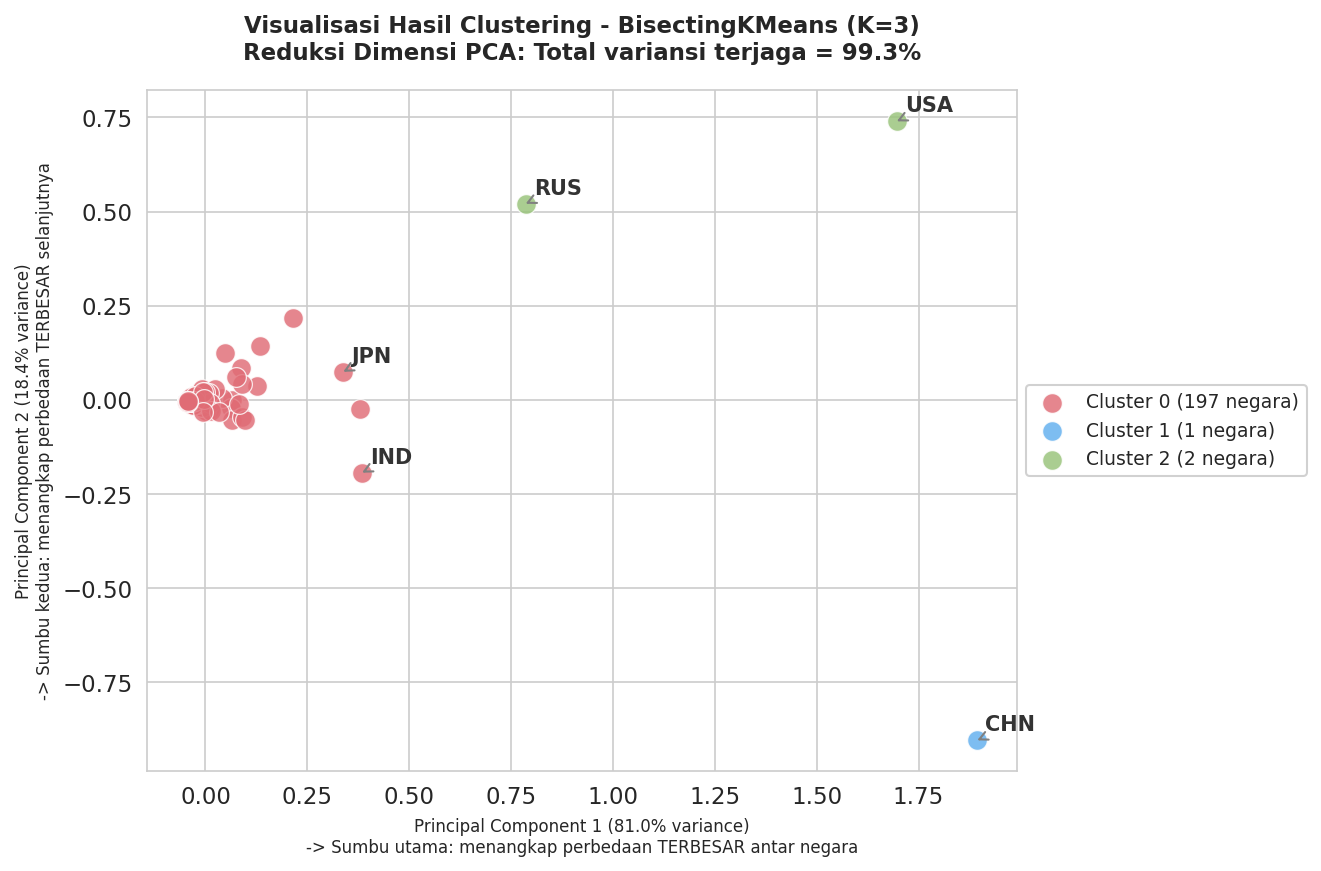

-> Grafik 5 disimpan: grafik5_scatter_pca_cluster.png


In [20]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full)
variance_explained = pca.explained_variance_ratio_ * 100
total_variance     = variance_explained.sum()
fig, ax = plt.subplots(figsize=(9,6 ))
for cluster_id in range(K):
    mask  = labels_bkm == cluster_id
    count = mask.sum()
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
        c=CLUSTER_COLORS[cluster_id],
        label=f'Cluster {cluster_id} ({count} negara)',
        s=90, alpha=0.82,
        edgecolors='white', linewidths=0.6)
ANNOTATE = ['CHN', 'USA', 'RUS', 'IND', 'JPN']
df_feat = df_feat.reset_index(drop=True)
for country_code in ANNOTATE:
    if country_code not in df_feat['country'].values:
        continue
    idx   = df_feat[df_feat['country'] == country_code].index[0]
    cname = country_code
    ax.annotate(cname,
        xy=(X_pca[idx, 0], X_pca[idx, 1]),
        xytext=(X_pca[idx, 0] + 0.02, X_pca[idx, 1] + 0.025),
        fontsize=10, fontweight='bold', color='#333',
        arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.set_title(f'Visualisasi Hasil Clustering - BisectingKMeans (K={K})\n'f'Reduksi Dimensi PCA: Total variansi terjaga = {total_variance:.1f}%',fontsize=11, fontweight='bold', pad=15)
ax.set_xlabel(f'Principal Component 1 ({variance_explained[0]:.1f}% variance)\n''-> Sumbu utama: menangkap perbedaan TERBESAR antar negara',fontsize=8)
ax.set_ylabel(f'Principal Component 2 ({variance_explained[1]:.1f}% variance)\n''-> Sumbu kedua: menangkap perbedaan TERBESAR selanjutnya',fontsize=8)
ax.legend(fontsize=12, loc='upper right', framealpha=0.9)
handles, labels_legend = ax.get_legend_handles_labels()
ax.legend(fontsize=9,loc='center left',bbox_to_anchor=(1, 0.5),framealpha=0.9)
plt.tight_layout()
plt.savefig('grafik5_scatter_pca_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("-> Grafik 5 disimpan: grafik5_scatter_pca_cluster.png")

## Grafik Pertumbuhan Emisi CO2 Tahunan (China, USA, Russia)

Grafik ini menunjukkan perubahan emisi CO2 dari tahun ke tahun untuk tiga negara besar: China, Amerika Serikat, dan Rusia. Nilai positif berarti terjadi peningkatan emisi dibandingkan tahun sebelumnya, sedangkan nilai negatif menunjukkan penurunan.

**Insight:**
*   **China:** Menunjukkan pertumbuhan emisi yang sangat dinamis, dengan kenaikan dan penurunan drastis, terutama di awal abad ke-21. Ini sangat berkorelasi dengan periode industrialisasi dan pertumbuhan ekonomi yang pesat. Fluktuasi tajam mungkin juga mencerminkan kebijakan energi, pembangunan infrastruktur besar, dan siklus ekonomi.
*   **USA:** Pertumbuhan emisi cenderung "statis" atau berfluktuasi di sekitar nol, bahkan menunjukkan periode penurunan yang konsisten. Hal ini mengindikasikan bahwa sebagai negara dengan ekonomi yang sudah matang, AS mungkin telah mencapai puncak emisinya dan mulai mengimplementasikan kebijakan lingkungan, transisi energi, dan peningkatan efisiensi yang menstabilkan atau mengurangi emisi karbonnya.
*   **Russia:** Fluktuasi yang signifikan, kemungkinan dipengaruhi oleh perubahan ekonomi dan politik pasca-Uni Soviet.

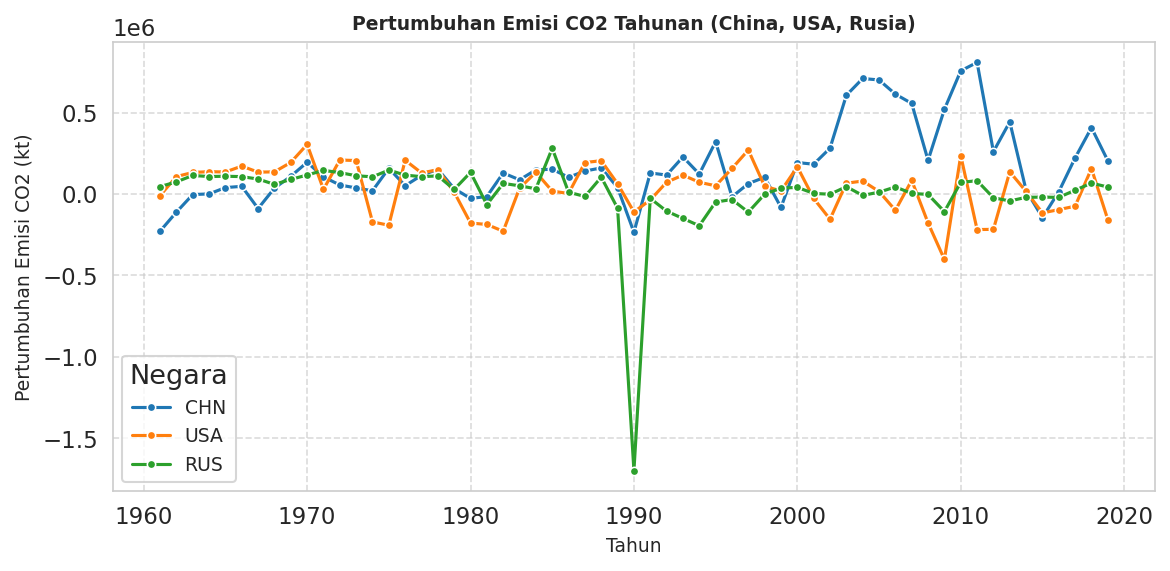

In [21]:
countries_to_plot = ['CHN', 'USA', 'RUS']
df_top_countries = df[df['country_code'].isin(countries_to_plot)].copy()

# Calculate year-on-year growth
df_top_countries['growth'] = df_top_countries.groupby('country_code')['value'].diff()

plt.figure(figsize=(8, 4))
for country_code in countries_to_plot:
    country_data = df_top_countries[df_top_countries['country_code'] == country_code]
    sns.lineplot(x='year', y='growth', data=country_data, label=country_code, marker='o', markersize=4)

plt.title('Pertumbuhan Emisi CO2 Tahunan (China, USA, Rusia)', fontsize=9, fontweight='bold')
plt.xlabel('Tahun', fontsize=9)
plt.ylabel('Pertumbuhan Emisi CO2 (kt)',fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=9, title='Negara')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafik_pertumbuhan_emisi_tahunan.png', dpi=150, bbox_inches='tight')
plt.show()

# **RINGKASAN CLUSTER + LABEL INTERPRETATIF**

Setelah cluster terbentuk, kita beri label bermakna berdasarkan rata-rata emisi setiap cluster.

* Cluster dengan rata-rata emisi TERENDAH = "Emisi Rendah"
* Cluster dengan rata-rata emisi TERTINGGI  = "Emisi Tinggi"

In [22]:
df_feat['cluster'] = labels_bkm
print("\n--- Karakteristik Rata-rata Tiap Cluster ---")
summary = df_feat.groupby('cluster')[FEATURES].mean().round(2)
print(summary.to_string())
print("\n--- Jumlah Negara per Cluster ---")
counts = df_feat['cluster'].value_counts().sort_index()
print(counts.to_string())
# Label otomatis berdasarkan ranking rata-rata emisi
mean_per_cluster = df_feat.groupby('cluster')['mean'].mean()
sorted_clusters  = mean_per_cluster.sort_values().index.tolist()
label_map = {sorted_clusters[0]: 'Emisi Rendah',sorted_clusters[1]: 'Emisi Sedang',sorted_clusters[2]: 'Emisi Tinggi',}
df_feat['label'] = df_feat['cluster'].map(label_map)
print("\n--- Label Cluster & Contoh Negara ---")
for c in sorted_clusters:
    n      = counts[c]
    m      = mean_per_cluster[c]
    lbl    = label_map[c]
    negara = df_feat[df_feat['cluster'] == c]['country'].head(6).tolist()
    print(f"\n  Cluster {c} [{lbl}]")
    print(f"    Jumlah negara    : {n}")
    print(f"    Rata-rata emisi  : {m:,.0f} kt")
    print(f"    Contoh negara    : {negara}")


--- Karakteristik Rata-rata Tiap Cluster ---
               mean         std      growth      trend     mean_p1     mean_p2     mean_p3
cluster                                                                                   
0          58365.38    24102.09    58480.92     939.17    39698.75    56330.76    79059.12
1        3599957.52  3279391.97  9926493.42  172760.97   813522.85  2349707.26  7636642.46
2        3487070.10   783389.30  1090988.37    8049.77  3182571.70  3804001.34  3474637.27

--- Jumlah Negara per Cluster ---
cluster
0    197
1      1
2      2

--- Label Cluster & Contoh Negara ---

  Cluster 0 [Emisi Rendah]
    Jumlah negara    : 197
    Rata-rata emisi  : 58,365 kt
    Contoh negara    : ['ABW', 'AFG', 'AGO', 'ALB', 'AND', 'ARG']

  Cluster 2 [Emisi Sedang]
    Jumlah negara    : 2
    Rata-rata emisi  : 3,487,070 kt
    Contoh negara    : ['RUS', 'USA']

  Cluster 1 [Emisi Tinggi]
    Jumlah negara    : 1
    Rata-rata emisi  : 3,599,958 kt
    Contoh negara   

# **SIMPAN HASIL AKHIR**

In [23]:
import joblib
joblib.dump(best_bkm, 'model_bisecting_kmeans.pkl')
joblib.dump(scaler,   'scaler.pkl')
country_name_map = df.groupby('country_code')['country_name'].first()
df_feat['country_name'] = df_feat['country'].map(country_name_map)
df_export = df_feat[['country', 'country_name', 'cluster', 'label','mean', 'std', 'growth', 'trend', 'mean_p1', 'mean_p2', 'mean_p3']].copy()
df_export.columns = ['country_code', 'country_name', 'cluster', 'label','mean', 'std', 'growth', 'trend', 'mean_p1', 'mean_p2', 'mean_p3']
df_export = df_export.sort_values('cluster')
df_export.to_csv('clustering_results.csv', index=False)
print("FILE TERSIMPAN:")
print("  model_bisecting_kmeans.pkl   model terbaik")
print("  scaler.pkl                   normalisasi MinMaxScaler")
print("  clustering_results.csv       hasil cluster semua negara")
print("  grafik1_eda_distribusi_tren.png")
print("  grafik2_eda_korelasi_fitur.png")
print("  grafik3_stability_test.png")
print("  grafik4_model_comparison.png")
print("  grafik5_scatter_pca_cluster.png")

FILE TERSIMPAN:
  model_bisecting_kmeans.pkl   model terbaik
  scaler.pkl                   normalisasi MinMaxScaler
  clustering_results.csv       hasil cluster semua negara
  grafik1_eda_distribusi_tren.png
  grafik2_eda_korelasi_fitur.png
  grafik3_stability_test.png
  grafik4_model_comparison.png
  grafik5_scatter_pca_cluster.png
